## 10. Kesimpulan & Insight Bisnis

**Ringkasan teknis**
- Kedua model memprediksi churn dengan baik (Accuracy ~0.88, F1-Score ~0.91 pada kelas churn).
- Menariknya, **Logistic Regression yang sederhana tampil setara — bahkan sedikit lebih unggul** dibanding Random Forest (F1 ~0.917 vs ~0.915, ROC-AUC ~0.960 vs ~0.953). Pelajaran penting: **model yang lebih kompleks tidak selalu lebih baik**; baseline yang rapi sudah sangat kuat saat polanya jelas.
- Metrik dilihat menyeluruh (Precision, Recall, F1) - bukan hanya Accuracy - karena data tidak seimbang (~71% churn).

**Insight bisnis (paling penting untuk dijelaskan ke manajer non-teknis)**
1. Jumlah keluhan adalah prediktor churn terkuat. Pelanggan dengan banyak keluhan hampir pasti berhenti langganan (8+ keluhan -> ~99% churn).
2. Rekomendasi: Bentuk sistem *early warning* - begitu seorang pelanggan mencapai ambang keluhan tertentu (mis. 4+ keluhan), tim retensi langsung menghubungi dan menawarkan solusi/insentif.
3. Tingkatkan kualitas penyelesaian keluhan; menurunkan keluhan = menurunkan churn.

**Langkah lanjutan (next steps)**
- Hyperparameter tuning (mis. GridSearchCV).
- Coba teknik penyeimbang data (SMOTE / class_weight).
- Deploy model sederhana (mis. Streamlit) agar bisa dipakai tim bisnis.

---
*Dibuat sebagai proyek portfolio Machine Learning - klasifikasi (supervised learning).*

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve,
)

# Pengaturan tampilan
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
RANDOM_STATE = 42
print("Library siap ✅")

Library siap ✅


## 2. Load Data

In [2]:
import os

# Path relatif agar notebook bisa dijalankan dari folder notebooks/ maupun root repo
DATA_PATH = "../data/customer_churn_dummy.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/customer_churn_dummy.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,umur,lama_berlangganan,tagihan_bulanan,jumlah_keluhan,jumlah_login,paket_premium,churn
0,56,24,1221151,2,244,0,0
1,69,65,210380,1,39,0,0
2,46,18,386243,9,156,0,1
3,32,44,562422,13,167,1,1
4,60,57,1257447,4,157,0,0


In [3]:
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print()
df.info()

Jumlah baris : 10,000
Jumlah kolom : 7

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   umur               10000 non-null  int64
 1   lama_berlangganan  10000 non-null  int64
 2   tagihan_bulanan    10000 non-null  int64
 3   jumlah_keluhan     10000 non-null  int64
 4   jumlah_login       10000 non-null  int64
 5   paket_premium      10000 non-null  int64
 6   churn              10000 non-null  int64
dtypes: int64(7)
memory usage: 547.0 KB


**Kamus Data (Data Dictionary)**

| Kolom | Arti | Tipe |
|---|---|---|
| `umur` | Umur pelanggan (tahun) | numerik |
| `lama_berlangganan` | Lama berlangganan (bulan) | numerik |
| `tagihan_bulanan` | Tagihan per bulan (Rupiah) | numerik |
| `jumlah_keluhan` | Jumlah keluhan yang pernah diajukan | numerik |
| `jumlah_login` | Jumlah login ke aplikasi | numerik |
| `paket_premium` | Apakah pakai paket premium (1) atau tidak (0) | biner |
| `churn` | **Target** — berhenti langganan (1) atau tetap (0) | biner |

## 3. Memahami Data (Data Understanding)

In [4]:
# Ringkasan statistik tiap kolom numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
umur,"10,000.00",43.54,14.91,18.00,31.00,43.00,56.00,69.00
lama_berlangganan,"10,000.00",36.04,20.52,1.00,18.00,36.00,54.00,71.00
tagihan_bulanan,"10,000.00","793,855.35","404,750.24","100,056.00","442,326.25","791,957.50","1,143,558.75","1,499,996.00"
jumlah_keluhan,"10,000.00",7.08,4.28,0.00,3.00,7.00,11.00,14.00
jumlah_login,"10,000.00",150.05,86.91,0.00,74.00,150.00,226.00,299.00
paket_premium,"10,000.00",0.30,0.46,0.00,0.00,0.00,1.00,1.00
churn,"10,000.00",0.71,0.45,0.00,0.00,1.00,1.00,1.00


In [5]:
# Distribusi target: seberapa banyak yang churn?
dist = df["churn"].value_counts().rename({0: "Tetap (0)", 1: "Churn (1)"})
dist_pct = df["churn"].value_counts(normalize=True).round(3) * 100
print("Jumlah:")
print(dist)
print("\nPersentase (%):")
print(dist_pct.rename({0: "Tetap (0)", 1: "Churn (1)"}))

Jumlah:
churn
Churn (1)    7118
Tetap (0)    2882
Name: count, dtype: int64

Persentase (%):
churn
Churn (1)   71.20
Tetap (0)   28.80
Name: proportion, dtype: float64


> ⚠️ **Catatan penting — data tidak seimbang (imbalanced).**
> Kelas `churn = 1` justru mayoritas (~71%). Artinya kalau model asal menebak
> "semua churn", akurasinya sudah ~71% padahal tidak berguna. Karena itu kita
> **tidak boleh hanya melihat Accuracy** — kita pakai **Precision, Recall, F1-Score,
> dan Confusion Matrix**.

## 4. Data Cleaning

In [6]:
# 4.1 Cek missing value
missing = df.isna().sum()
print("Missing value per kolom:")
print(missing)
print(f"\nTotal missing value: {missing.sum()}")

Missing value per kolom:
umur                 0
lama_berlangganan    0
tagihan_bulanan      0
jumlah_keluhan       0
jumlah_login         0
paket_premium        0
churn                0
dtype: int64

Total missing value: 0


In [7]:
# 4.2 Cek data duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

# Kalau ada duplikat, hapus (di sini sebagai praktik standar)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Jumlah baris setelah drop duplikat: {len(df):,}")

Jumlah baris duplikat: 0
Jumlah baris setelah drop duplikat: 10,000


✅ **Hasil cleaning:** Dataset ini **bersih** — tidak ada missing value maupun
duplikat. Kode di atas tetap ditampilkan sebagai praktik standar yang harus selalu
dilakukan, karena di dunia nyata data jarang sebersih ini.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribusi Target (Churn vs Tetap)

C:\Users\Ignatius\AppData\Local\Temp\claude\ipykernel_24452\442204613.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="churn", palette=["#2ecc71", "#e74c3c"])
C:\Users\Ignatius\AppData\Local\Temp\claude\ipykernel_24452\442204613.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Tetap (0)", "Churn (1)"])


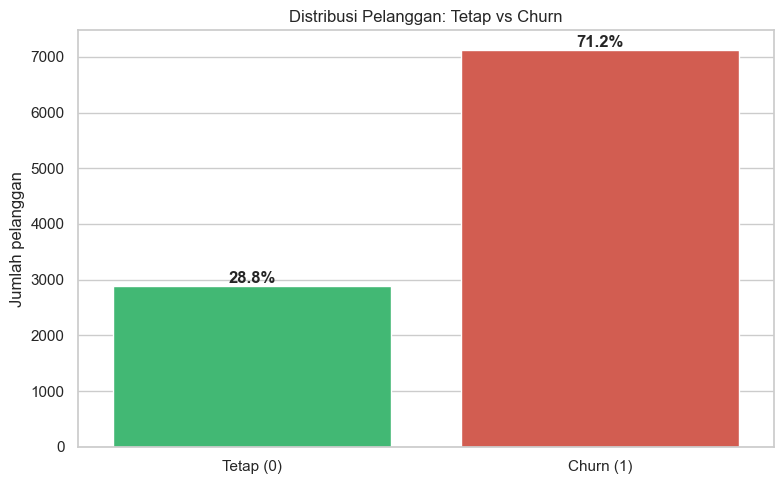

In [8]:
ax = sns.countplot(data=df, x="churn", palette=["#2ecc71", "#e74c3c"])
ax.set_title("Distribusi Pelanggan: Tetap vs Churn")
ax.set_xticklabels(["Tetap (0)", "Churn (1)"])
ax.set_xlabel("")
ax.set_ylabel("Jumlah pelanggan")
total = len(df)
for p in ax.patches:
    pct = p.get_height() / total * 100
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 Distribusi Fitur Numerik

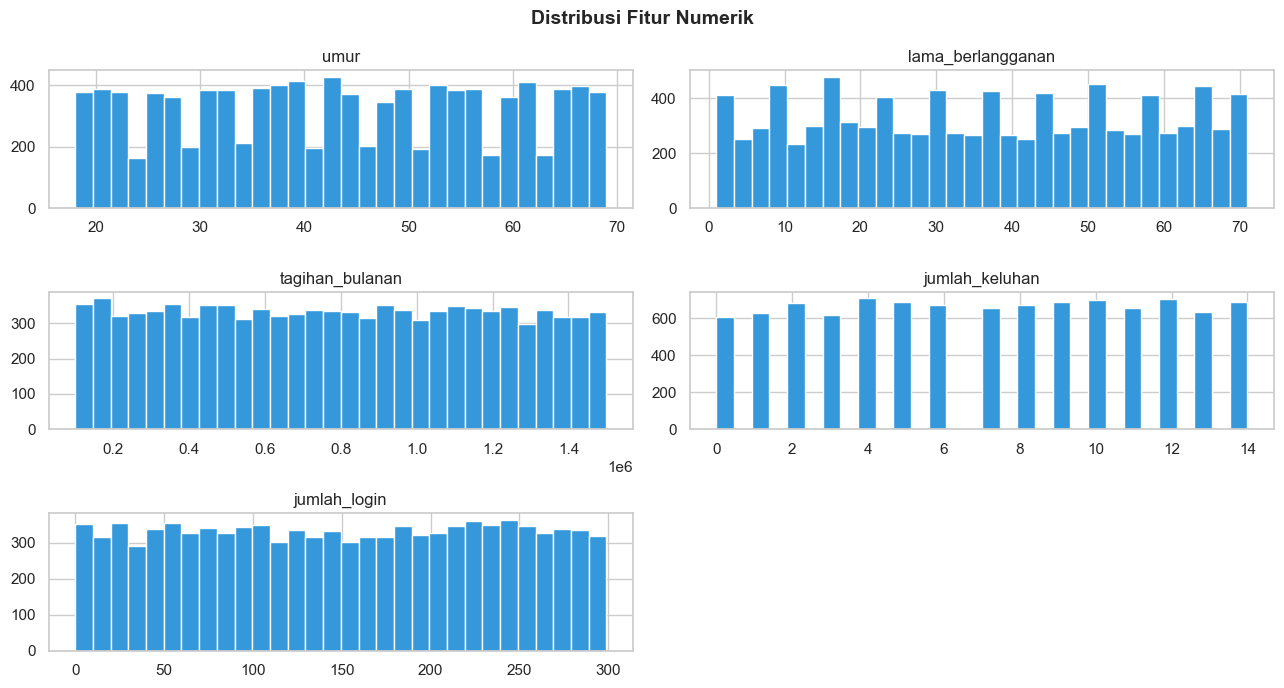

In [9]:
fitur_numerik = ["umur", "lama_berlangganan", "tagihan_bulanan",
                 "jumlah_keluhan", "jumlah_login"]
df[fitur_numerik].hist(bins=30, figsize=(13, 7), color="#3498db", edgecolor="white")
plt.suptitle("Distribusi Fitur Numerik", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 Hubungan Jumlah Keluhan dengan Churn (driver utama)

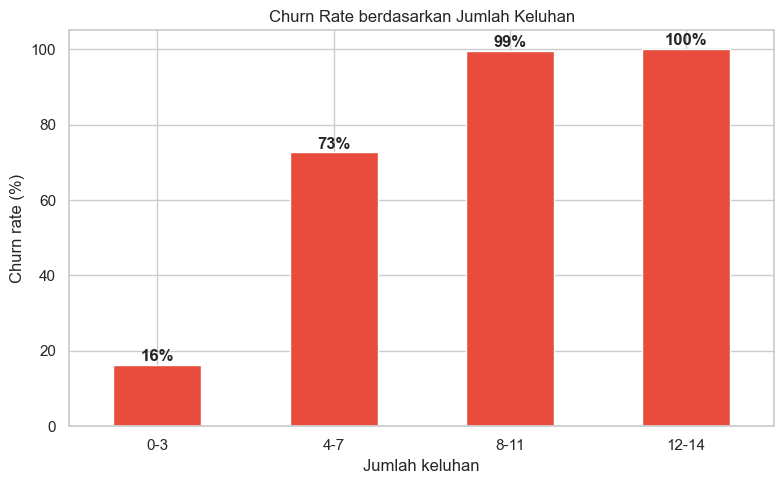

In [10]:
# Kelompokkan jumlah keluhan menjadi rentang, lalu hitung churn rate-nya
df_temp = df.copy()
df_temp["kel_bin"] = pd.cut(df_temp["jumlah_keluhan"],
                            bins=[-1, 3, 7, 11, 14],
                            labels=["0-3", "4-7", "8-11", "12-14"])
churn_per_keluhan = df_temp.groupby("kel_bin", observed=True)["churn"].mean() * 100

ax = churn_per_keluhan.plot(kind="bar", color="#e74c3c", edgecolor="white")
ax.set_title("Churn Rate berdasarkan Jumlah Keluhan")
ax.set_xlabel("Jumlah keluhan")
ax.set_ylabel("Churn rate (%)")
ax.set_ylim(0, 105)
for i, v in enumerate(churn_per_keluhan):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

🔎 **Temuan paling penting:** Semakin banyak keluhan, semakin tinggi peluang churn.
Pelanggan dengan **8+ keluhan hampir pasti berhenti langganan** (~99–100%), sedangkan
yang keluhannya sedikit (0–3) churn-nya hanya ~16%. Ini sinyal bisnis yang sangat kuat.

### 5.4 Korelasi Antar Fitur

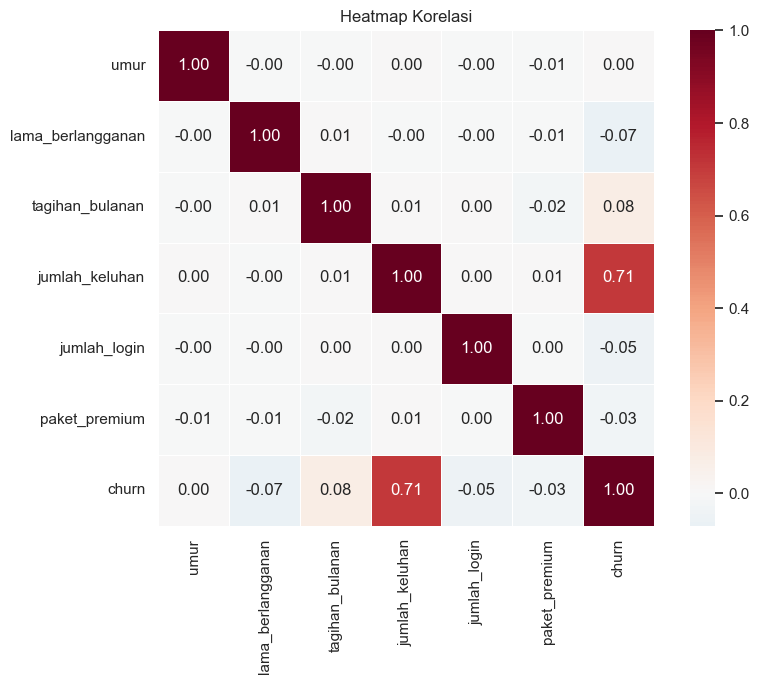

Korelasi tiap fitur terhadap churn (urut):
jumlah_keluhan       0.71
tagihan_bulanan      0.08
umur                 0.00
paket_premium       -0.03
jumlah_login        -0.05
lama_berlangganan   -0.07
Name: churn, dtype: float64


In [11]:
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Heatmap Korelasi")
plt.tight_layout()
plt.show()

print("Korelasi tiap fitur terhadap churn (urut):")
print(corr["churn"].drop("churn").sort_values(ascending=False))

**Insight EDA:**
- `jumlah_keluhan` punya korelasi sangat kuat dengan churn (**+0.71**) → faktor utama.
- `lama_berlangganan` korelasi negatif lemah → makin lama berlangganan, sedikit lebih
  loyal (masuk akal secara bisnis).
- `umur`, `jumlah_login`, `paket_premium`, `tagihan_bulanan` pengaruhnya kecil.

## 6. Feature Engineering

Membuat fitur baru agar model lebih informatif dan lebih mudah diinterpretasi:
- **`tenure_group`** — mengelompokkan `lama_berlangganan` menjadi kategori
  (Baru / Menengah / Lama / Setia).
- **`rasio_keluhan_login`** — jumlah keluhan dibandingkan aktivitas login.
  Pelanggan yang sering komplain tapi jarang login bisa jadi sinyal ketidakpuasan.

In [12]:
df["tenure_group"] = pd.cut(
    df["lama_berlangganan"],
    bins=[0, 12, 24, 48, 72],
    labels=["Baru (0-12)", "Menengah (13-24)", "Lama (25-48)", "Setia (49-72)"],
)

df["rasio_keluhan_login"] = df["jumlah_keluhan"] / (df["jumlah_login"] + 1)

df[["lama_berlangganan", "tenure_group",
    "jumlah_keluhan", "jumlah_login", "rasio_keluhan_login"]].head()

,lama_berlangganan,tenure_group,jumlah_keluhan,jumlah_login,rasio_keluhan_login
0,24,Menengah (13-24),2,244,0.01
1,65,Setia (49-72),1,39,0.03
2,18,Menengah (13-24),9,156,0.06
3,44,Lama (25-48),13,167,0.08
4,57,Setia (49-72),4,157,0.03


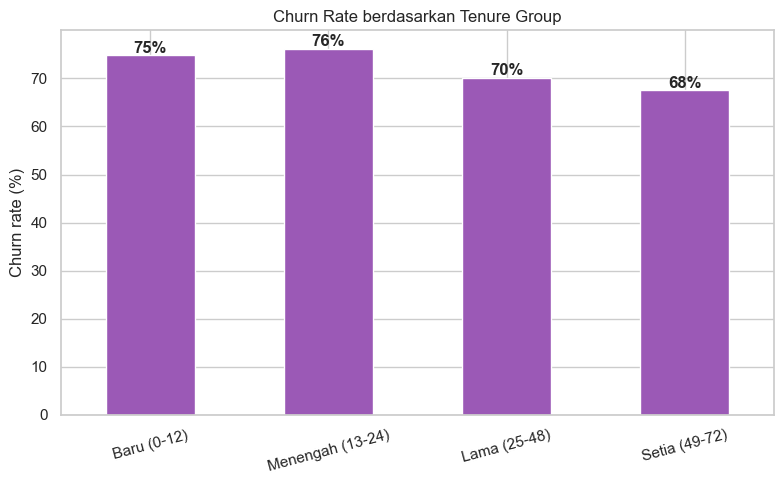

In [13]:
# Cek churn rate per tenure_group
churn_tenure = df.groupby("tenure_group", observed=True)["churn"].mean() * 100
ax = churn_tenure.plot(kind="bar", color="#9b59b6", edgecolor="white")
ax.set_title("Churn Rate berdasarkan Tenure Group")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("")
for i, v in enumerate(churn_tenure):
    ax.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Preprocessing

- Memisahkan fitur (`X`) dan target (`y`).
- Mengubah `tenure_group` (kategori) menjadi angka via **one-hot encoding**.
- Membagi data menjadi **train (80%)** dan **test (20%)** dengan `stratify=y`
  agar proporsi churn tetap sama di kedua bagian.

In [14]:
# One-hot encoding untuk fitur kategori
df_model = pd.get_dummies(df, columns=["tenure_group"], drop_first=True)

X = df_model.drop(columns=["churn"])
y = df_model["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Data latih : {X_train.shape[0]:,} baris")
print(f"Data uji   : {X_test.shape[0]:,} baris")
print(f"Jumlah fitur: {X_train.shape[1]}")
print(f"\nProporsi churn di data latih:\n{y_train.value_counts(normalize=True).round(3)}")

Data latih : 8,000 baris
Data uji   : 2,000 baris
Jumlah fitur: 10

Proporsi churn di data latih:
churn
1   0.71
0   0.29
Name: proportion, dtype: float64


## 8. Modeling

Kita mulai dari model sederhana sebagai **baseline**, lalu naik ke model yang lebih kuat:
1. **Logistic Regression** — baseline, cepat & mudah diinterpretasi (perlu scaling).
2. **Random Forest** — model ensemble yang biasanya lebih akurat.

### 8.1 Logistic Regression (Baseline)

In [15]:
# Logistic Regression sensitif terhadap skala, jadi dibungkus Pipeline + StandardScaler
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]
print("Logistic Regression selesai dilatih ✅")

Logistic Regression selesai dilatih ✅


### 8.2 Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("Random Forest selesai dilatih ✅")

Random Forest selesai dilatih ✅


## 9. Evaluasi Model

Kita bandingkan kedua model memakai beberapa metrik. Untuk data tidak seimbang,
**F1-Score** dan **Recall** lebih informatif daripada Accuracy.

In [17]:
def hitung_metrik(nama, y_true, y_pred, y_proba):
    return {
        "Model": nama,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

hasil = pd.DataFrame([
    hitung_metrik("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    hitung_metrik("Random Forest", y_test, y_pred_rf, y_proba_rf),
]).set_index("Model")

hasil.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.882,0.919,0.915,0.917,0.960
Random Forest,0.878,0.914,0.915,0.915,0.953


### 9.1 Confusion Matrix

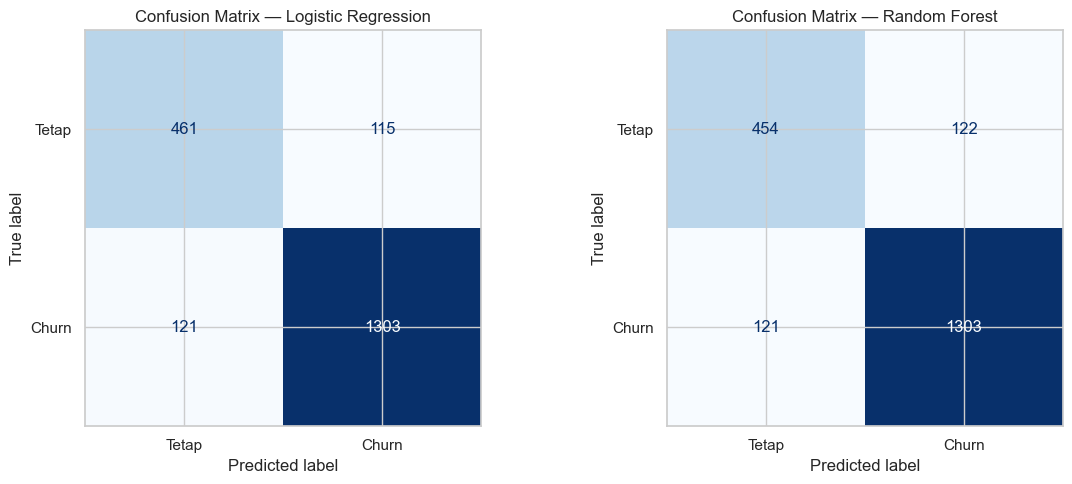

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nama, y_pred) in zip(
    axes, [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Tetap", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {nama}")
plt.tight_layout()
plt.show()

### 9.2 Classification Report (Random Forest)

In [19]:
print("Classification Report — Random Forest\n")
print(classification_report(y_test, y_pred_rf, target_names=["Tetap (0)", "Churn (1)"]))

Classification Report — Random Forest

              precision    recall  f1-score   support

   Tetap (0)       0.79      0.79      0.79       576
   Churn (1)       0.91      0.92      0.91      1424

    accuracy                           0.88      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.88      0.88      0.88      2000



### 9.3 Kurva ROC

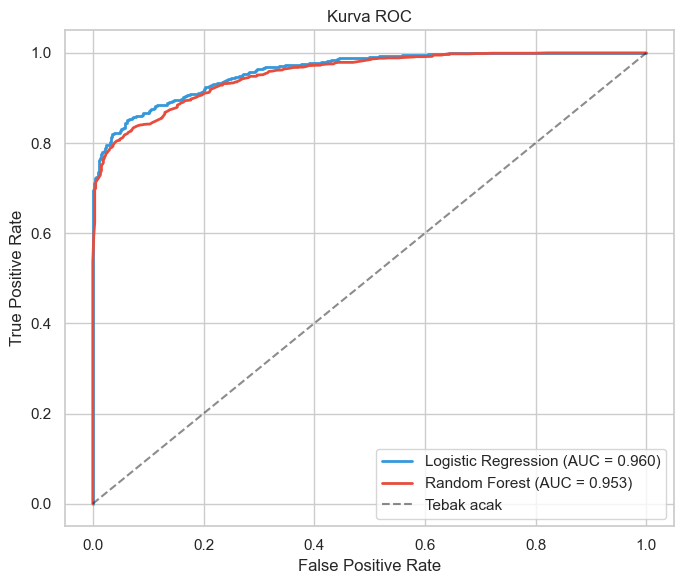

In [20]:
plt.figure(figsize=(7, 6))
for nama, y_proba, warna in [
    ("Logistic Regression", y_proba_lr, "#3498db"),
    ("Random Forest", y_proba_rf, "#e74c3c"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nama} (AUC = {auc:.3f})", color=warna, linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Tebak acak")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Kurva ROC")
plt.legend()
plt.tight_layout()
plt.show()

### 9.4 Feature Importance (Random Forest)

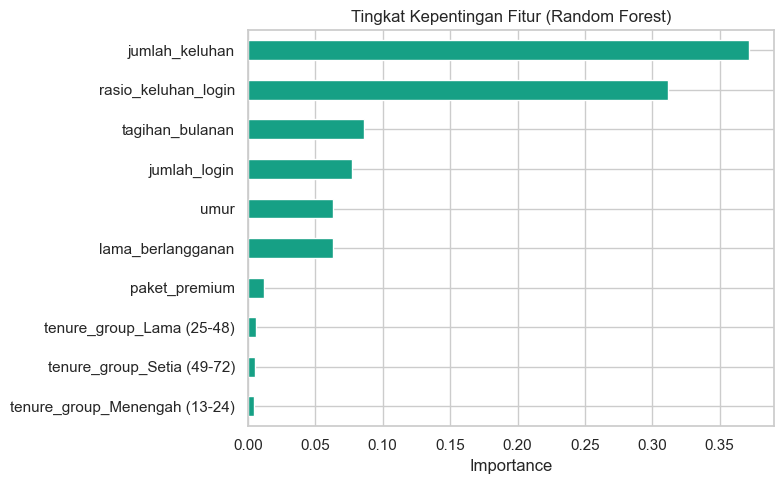

Fitur paling berpengaruh:
jumlah_keluhan        0.37
rasio_keluhan_login   0.31
tagihan_bulanan       0.09
jumlah_login          0.08
umur                  0.06
dtype: float64


In [21]:
importances = (
    pd.Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
)
ax = importances.plot(kind="barh", color="#16a085", edgecolor="white")
ax.set_title("Tingkat Kepentingan Fitur (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Fitur paling berpengaruh:")
print(importances.sort_values(ascending=False).head())

## 10. Kesimpulan & Insight Bisnis

**Ringkasan teknis**
- Kedua model berhasil memprediksi churn dengan baik; **Random Forest** sedikit lebih
  unggul pada F1-Score dan ROC-AUC.
- Metrik dilihat menyeluruh (Precision, Recall, F1) — bukan hanya Accuracy — karena
  data tidak seimbang.

**Insight bisnis (paling penting untuk dijelaskan ke manajer non-teknis)**
1. 🔥 **Jumlah keluhan adalah prediktor churn terkuat.** Pelanggan dengan banyak
   keluhan hampir pasti berhenti langganan.
2. 🛟 **Rekomendasi:** Bentuk sistem *early warning* — begitu seorang pelanggan
   mencapai ambang keluhan tertentu (mis. 4+ keluhan), tim retensi langsung
   menghubungi dan menawarkan solusi/insentif.
3. 📞 Tingkatkan kualitas penyelesaian keluhan; menurunkan keluhan = menurunkan churn.

**Langkah lanjutan (next steps)**
- Hyperparameter tuning (mis. `GridSearchCV`).
- Coba teknik penyeimbang data (SMOTE / `class_weight`).
- Deploy model sederhana (mis. Streamlit) agar bisa dipakai tim bisnis.

---
*Dibuat sebagai proyek portfolio Machine Learning — klasifikasi (supervised learning).*